In [1]:
from models.mllm_wrappers import LLaVA, Qwen, Janus, Qwen3_5, Molmo
from configuration_template import Config

config = Config()
config.input_type = 'simple'
config.task = 'grid'

img_kwargs = {
    "patch_size": config.patch_size*3,
    "patch_padding": config.grid_padding,
    "patch_pad_color": config.grid_pad_color,
}

generate_kwargs = {
        "max_new_tokens": config.max_new_tokens,
        "do_sample": True,
        "temperature": 0.8
    }

model_kwargs = {"cache_dir": config.model_cache_dir, "quant": config.quant}


print("Model ID: ", config.model_id)

Model = Qwen
model = Model(config.model_id, **model_kwargs)
print(f'Model: {model.__class__}')

/home/alesau/miniconda3/envs/mllm/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


model_version: Qwen2
model_type: Qwen
Model ID:  Qwen/Qwen2-VL-2B-Instruct


building Qwen model...


Loading weights: 100%|██████████| 729/729 [00:10<00:00, 67.31it/s] 
The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Model: <class 'models.mllm_wrappers.Qwen'>


In [2]:
## set randomness
model_mode = 'random'

if model_mode == 'random':
    ## set randomness
    model.model.generation_config.temperature = 0.7
    model.model.generation_config.do_sample = True
    model.model.generation_config.top_p = 0.9
    model.model.generation_config.top_k = 50
else:
    ## set deterministic
    model.model.generation_config.temperature = 0.01
    model.model.generation_config.do_sample = True
    model.model.generation_config.top_p = 0.001
    model.model.generation_config.top_k = 1


In [3]:

SPEAKER_PROMPT_ONE = 'In this image you can see three colors. Describe the color, which is defined throught the following coordinates: '
SPEAKER_PROMPT_TWO = '. I see the three colors in a different order than you do and i dont know which one you should describe. Describe the defined color in such a way, that I can identify it among the three colors. Do not refer to the color as left, middle or right. Do not mention any location or coordinates at all. Just describe the needed color. If necessary, you can also describe whats distinctive about the other colors.'


In [11]:
import pandas as pd
import os.path as osp
data_df = pd.read_json(osp.join(config.data_dir, "color_patch_data.json"))
new_responses = []
old_responses = []
entries = []

Entry 46956
identifier                                                   8762-f:16
gameid                                                          8762-f
roundNum                                                            16
condition                                                        split
success                                                           True
hls_values                 [[35, 50, 84], [37, 50, 65], [315, 50, 84]]
s_order_t_distr1_distr2                                      [0, 1, 2]
l_order_t_distr1_distr2                                      [0, 1, 2]
conversation                          [[speaker, bright orange, None]]
n_utterances                                                         1
Name: 46956, dtype: object
Img size:  (300, 300)
Img size:  (300, 300)
Img size:  (300, 300)
Img Size:  (1050, 350)
s_order_t_distr1_distr2: [0, 1, 2]
Full prompt: In this image you can see three colors. Describe the color, which is defined throught the following coordinates:  

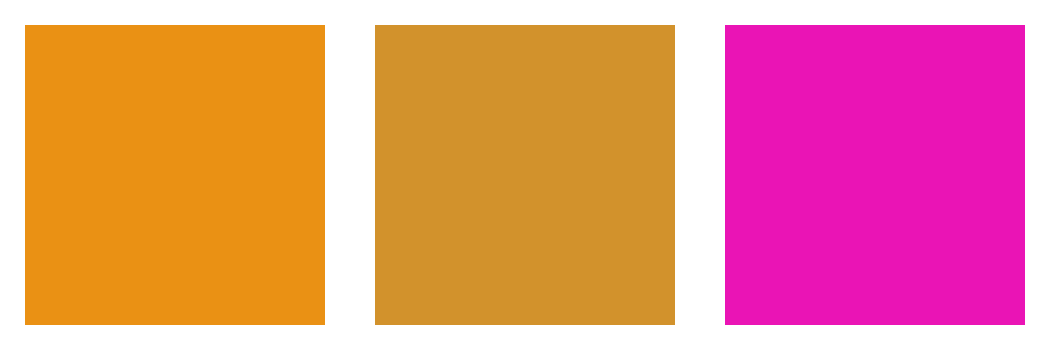

Position described by speaker: left
Response sentence: The defined color is a warm, golden-brown shade, approximately in the range of 230-245 on the HSB (Hue, Saturation, Brightness) color model. This color has a rich, earthy tone with a slight undertone of orange and is quite versatile in use. 


Entry 21163
identifier                                                         9709-7:24
gameid                                                                9709-7
roundNum                                                                  24
condition                                                              close
success                                                                False
hls_values                     [[178, 50, 13], [165, 50, 27], [177, 50, 23]]
s_order_t_distr1_distr2                                            [1, 0, 2]
l_order_t_distr1_distr2                                            [1, 0, 2]
conversation               [[listener, This one is hard, None], [speaker,

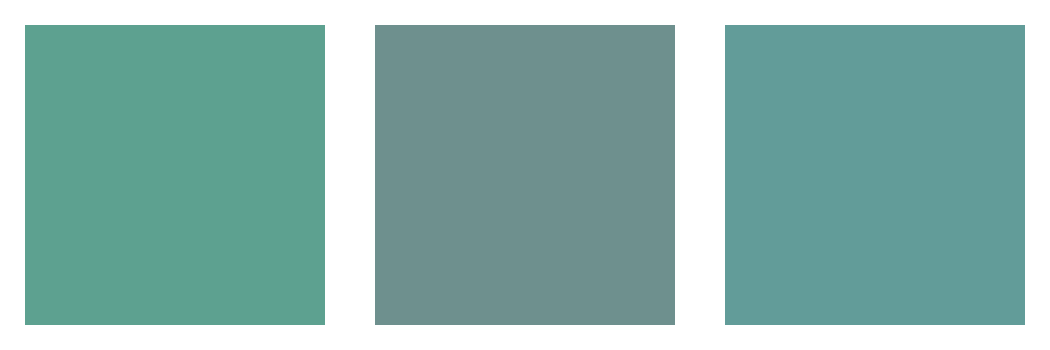

Position described by speaker: middle
Response sentence: The color in the center, defined by the coordinates [375, 25] to [675, 325], is a soft, muted greenish-blue. It has a gentle and soothing appearance, making it suitable for applications that require a calming or natural feel. 


Entry 38273
identifier                                                    8547-9:5
gameid                                                          8547-9
roundNum                                                             5
condition                                                          far
success                                                           True
hls_values                 [[198, 50, 67], [73, 50, 71], [16, 50, 73]]
s_order_t_distr1_distr2                                      [1, 2, 0]
l_order_t_distr1_distr2                                      [1, 2, 0]
conversation                                   [[speaker, blue, None]]
n_utterances                                                   

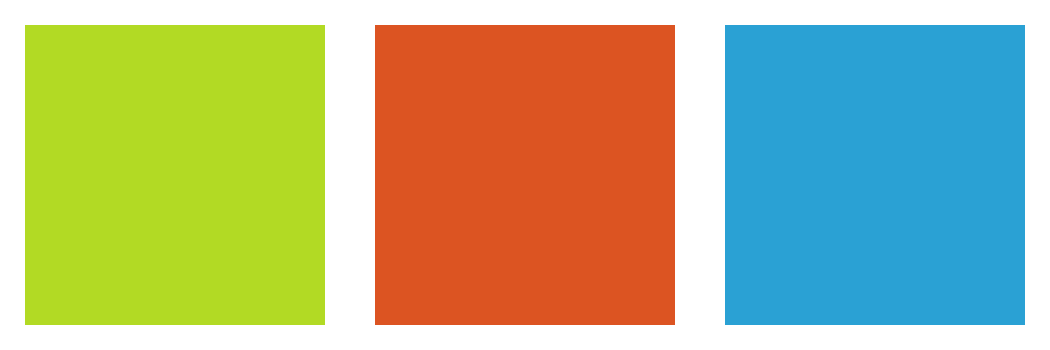

Position described by speaker: right
Response sentence: The color described is the blue square. It has a distinct hue that stands out as the darkest blue among the three, making it visually distinct from the other two colors. 


Entry 31799
identifier                                                  6327-c:30
gameid                                                         6327-c
roundNum                                                           30
condition                                                         far
success                                                          True
hls_values                 [[7, 50, 62], [111, 50, 80], [28, 50, 99]]
s_order_t_distr1_distr2                                     [1, 0, 2]
l_order_t_distr1_distr2                                     [1, 0, 2]
conversation                                   [[speaker, Red, None]]
n_utterances                                                        1
Name: 31799, dtype: object
Img size:  (300, 300)
Img size: 

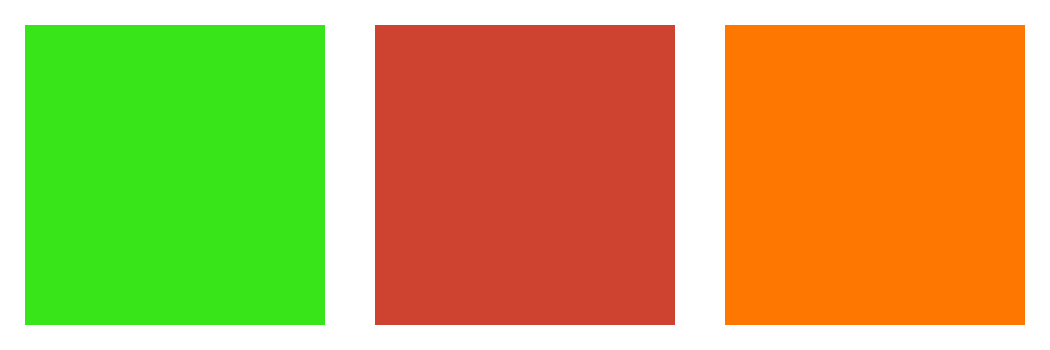

Position described by speaker: middle
Response sentence: The color described as having a distinctive feature that is not present in the other two colors is the "red" square. It stands out because it has a more vibrant and saturated hue compared to the green and orange squares. 


Entry 45025
identifier                                                   4893-9:33
gameid                                                          4893-9
roundNum                                                            33
condition                                                        split
success                                                           True
hls_values                 [[317, 50, 19], [339, 50, 76], [29, 50, 3]]
s_order_t_distr1_distr2                                      [1, 2, 0]
l_order_t_distr1_distr2                                      [1, 0, 2]
conversation                                  [[speaker, mauve, None]]
n_utterances                                                        

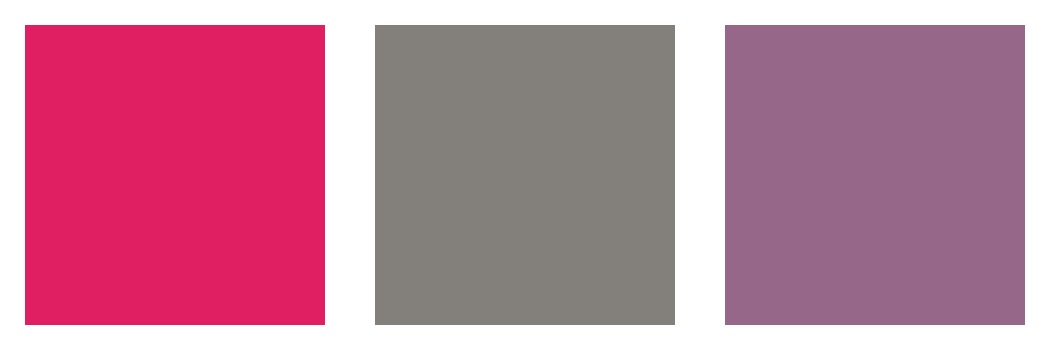

Position described by speaker: right
Response sentence: The color described as  [[725,25],[1025,325]] appears to be a light grey or silver-gray. It is a muted grayish tone with a slight tint of white, giving it a subtle, neutral appearance. 


Entry 40841
identifier                                                     3159-0:34
gameid                                                            3159-0
roundNum                                                              34
condition                                                          close
success                                                             True
hls_values                    [[167, 50, 1], [65, 50, 21], [119, 50, 3]]
s_order_t_distr1_distr2                                        [2, 1, 0]
l_order_t_distr1_distr2                                        [0, 2, 1]
conversation               [[speaker, the grey with purple tint?, None]]
n_utterances                                                           1
Name: 40841, d

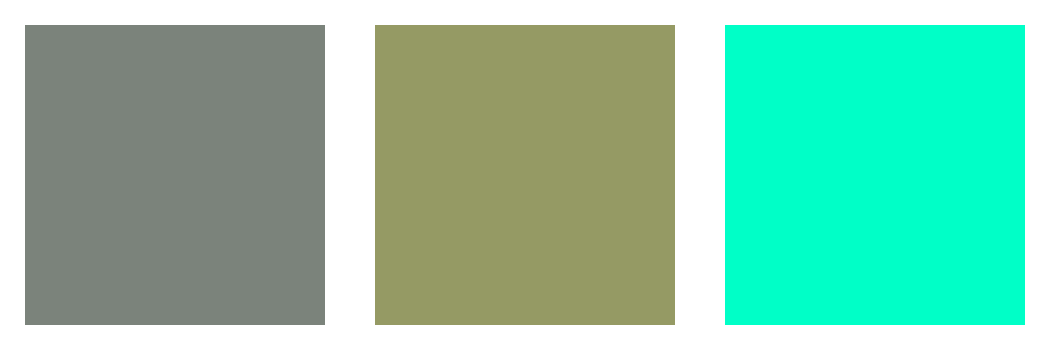

Position described by speaker: right
Response sentence: The color in the coordinates [725, 25] is a deep, dark green that resembles the color of a forest or a lush greenery. 


Entry 36126
identifier                                                      8535-b:2
gameid                                                            8535-b
roundNum                                                               2
condition                                                          close
success                                                            False
hls_values                 [[236, 50, 76], [281, 50, 55], [274, 50, 93]]
s_order_t_distr1_distr2                                        [1, 0, 2]
l_order_t_distr1_distr2                                        [2, 1, 0]
conversation                               [[speaker, royal blue, None]]
n_utterances                                                           1
Name: 36126, dtype: object
Img size:  (300, 300)
Img size:  (300, 300)
Img size: 

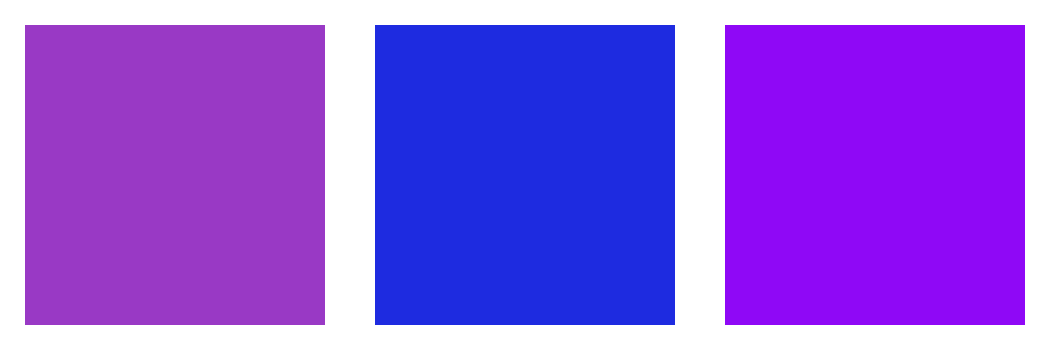

Position described by speaker: middle
Response sentence: The color described is a deep, rich purple. 


Entry 13108
identifier                                                    2580-b:16
gameid                                                           2580-b
roundNum                                                             16
condition                                                           far
success                                                            True
hls_values                 [[333, 50, 89], [309, 50, 7], [279, 50, 49]]
s_order_t_distr1_distr2                                       [1, 2, 0]
l_order_t_distr1_distr2                                       [0, 2, 1]
conversation                                    [[speaker, pink, None]]
n_utterances                                                          1
Name: 13108, dtype: object
Img size:  (300, 300)
Img size:  (300, 300)
Img size:  (300, 300)
Img Size:  (1050, 350)
s_order_t_distr1_distr2: [1, 2, 0]
Full prompt: 

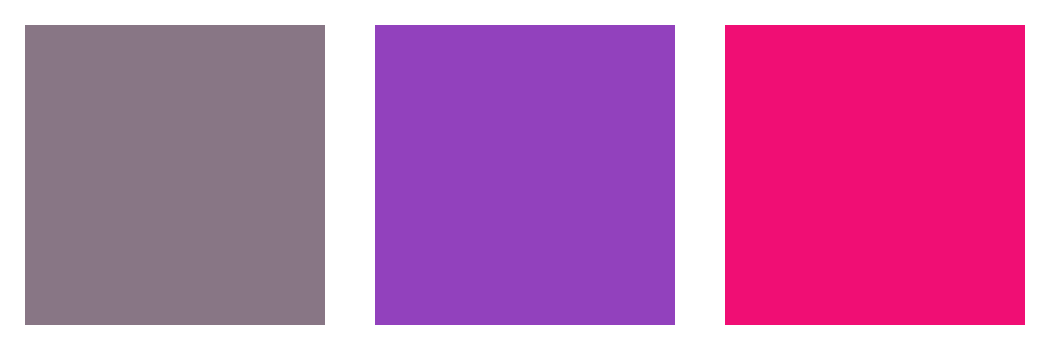

Position described by speaker: right
Response sentence: The color in the specified coordinates is a deep, rich purple that stands out prominently against the white background. 


Entry 44344
identifier                                                     5958-d:2
gameid                                                           5958-d
roundNum                                                              2
condition                                                         close
success                                                           False
hls_values                 [[235, 50, 25], [302, 50, 8], [300, 50, 22]]
s_order_t_distr1_distr2                                       [1, 2, 0]
l_order_t_distr1_distr2                                       [0, 2, 1]
conversation                             [[speaker, blue purple, None]]
n_utterances                                                          1
Name: 44344, dtype: object
Img size:  (300, 300)
Img size:  (300, 300)
Img size:  (300, 3

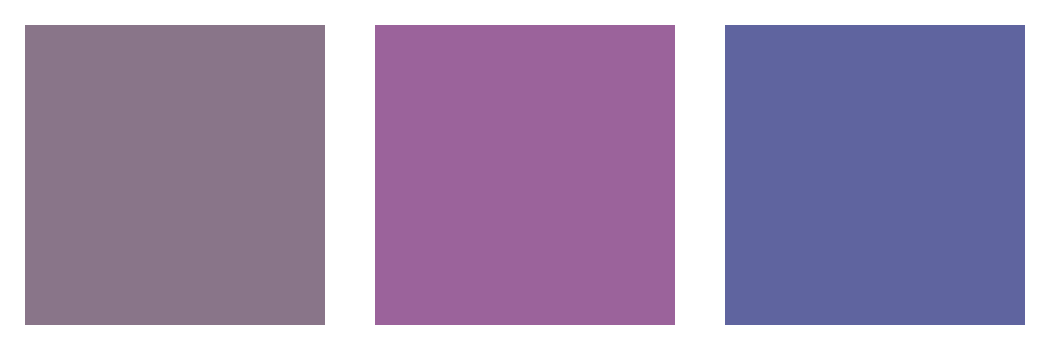

Position described by speaker: right
Response sentence: The color in the center, defined by coordinates [[725,25],[1025,325]], appears to be a deep, rich purple. This color is distinct from the other two colors, which are more muted and have a more uniform hue. 


Entry 5657
identifier                                                    4490-3:9
gameid                                                          4490-3
roundNum                                                             9
condition                                                        split
success                                                           True
hls_values                 [[47, 50, 90], [61, 50, 67], [163, 50, 93]]
s_order_t_distr1_distr2                                      [1, 0, 2]
l_order_t_distr1_distr2                                      [1, 2, 0]
conversation                      [[speaker, school bus yellow, None]]
n_utterances                                                         1
Name: 5657, dt

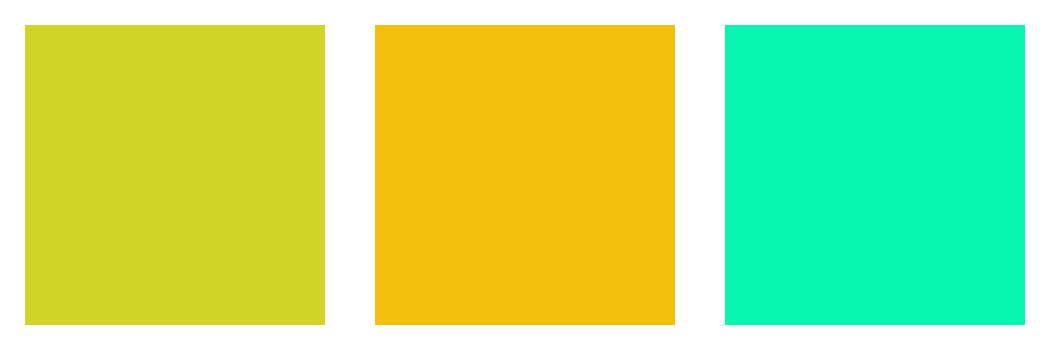

Position described by speaker: middle
Response sentence: The color in the specified coordinates is a warm yellow or light brownish-orange. It has a subtle gradient and appears to have a slight tinge of yellow in the middle. 




In [12]:
from data_prep.data_utils import build_patch_image_with_target_highlight


number_of_samples = 10
for i, entry in data_df.sample(n=number_of_samples, random_state=42).iterrows():
    print(f"Entry {i}")
    print(entry)
    img = build_patch_image_with_target_highlight(entry.hls_values, entry.s_order_t_distr1_distr2, **img_kwargs, highlight_target=False)
    print("Img Size: ", img.size)

    if(entry.s_order_t_distr1_distr2[0] == 0):
        bounding_box ="[[25,25],[325,325]]"
    elif(entry.s_order_t_distr1_distr2[1] == 0):
        bounding_box ="[[375,25],[675,325]]"
    elif(entry.s_order_t_distr1_distr2[2] == 0):
        bounding_box ="[[725,25],[1025,325]]"

    position = ""
    print(f"s_order_t_distr1_distr2: {entry.s_order_t_distr1_distr2}")
    entry.target = entry.s_order_t_distr1_distr2.index(0)
    if entry.target == 0:
        position = "left"
    elif entry.target == 1:
        position = "middle"
    elif entry.target == 2:
        position = "right"

    full_prompt = ' '.join([SPEAKER_PROMPT_ONE, bounding_box, SPEAKER_PROMPT_TWO])
    print(f"Full prompt: {full_prompt}")
    response_sentence = model.generate(full_prompt, img, **generate_kwargs)
    display(img)
    print(f"Position described by speaker: {position}")
    print(f"Response sentence: {response_sentence} \n\n")
    new_responses.append(response_sentence)
    entries.append(entry)

# Metrics

## BLEU

In [44]:
#!pip install nltk

from nltk.translate.bleu_score import sentence_bleu
from nltk.translate.meteor_score import meteor_score
import nltk
from rouge_score import rouge_scorer
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

#nltk.download('wordnet')

def utterances_to_dialogue_string(utterances):
    lines = [f'{intl}: {utt}' for intl, utt, _ in utterances]
    return '\n'.join(lines)

scorer_rouge = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=True)

for i in range(number_of_samples):
    reference = utterances_to_dialogue_string(entries[i].conversation)
    candidate = new_responses[i]
    rouge_scores = scorer_rouge.score(candidate, reference)
    score_meteor = meteor_score([reference.split()], candidate.split())
    print("Entry ", i  )
    print('BLEU 1-gram: ' + str(round(sentence_bleu([reference.split()], candidate.split(), weights=(1, 0, 0, 0)), 4)*100))
    print('BLEU 4-gram: ' + str(round(sentence_bleu([reference.split()], candidate.split(), weights=(0, 0, 0, 1)), 4)*100))
    print('ROUGE-1: ' + str(round(rouge_scores['rouge1'].fmeasure, 4)*100))
    print('ROUGE-L: ' + str(round(rouge_scores['rougeL'].fmeasure, 4)*100))
    print('METEOR: ' + str(round(score_meteor, 4)*100))
    #print('Individual 2-gram: %f' % sentence_bleu([reference.split()], candidate.split(), weights=(0, 1, 0, 0)))
    #print('Individual 3-gram: %f' % sentence_bleu([reference.split()], candidate.split(), weights=(0, 0, 1, 0)))
    #print('Individual 4-gram: %f' % sentence_bleu([reference.split()], candidate.split(), weights=(0, 0, 0, 1)))
    print()

Entry  0
BLEU 1-gram: 2.44
BLEU 4-gram: 0.0
ROUGE-1: 8.7
ROUGE-L: 8.7
METEOR: 7.35

Entry  1
BLEU 1-gram: 2.63
BLEU 4-gram: 0.0
ROUGE-1: 4.0
ROUGE-L: 4.0
METEOR: 3.65

Entry  2
BLEU 1-gram: 3.2300000000000004
BLEU 4-gram: 0.0
ROUGE-1: 6.0600000000000005
ROUGE-L: 6.0600000000000005
METEOR: 10.2

Entry  3
BLEU 1-gram: 0
BLEU 4-gram: 0
ROUGE-1: 4.760000000000001
ROUGE-L: 4.760000000000001
METEOR: 0.0

Entry  4
BLEU 1-gram: 0
BLEU 4-gram: 0
ROUGE-1: 0.0
ROUGE-L: 0.0
METEOR: 0.0

Entry  5
BLEU 1-gram: 4.35
BLEU 4-gram: 0.0
ROUGE-1: 6.9
ROUGE-L: 6.9
METEOR: 6.49

Entry  6
BLEU 1-gram: 0
BLEU 4-gram: 0
ROUGE-1: 0.0
ROUGE-L: 0.0
METEOR: 0.0

Entry  7
BLEU 1-gram: 0
BLEU 4-gram: 0
ROUGE-1: 0.0
ROUGE-L: 0.0
METEOR: 0.0

Entry  8
BLEU 1-gram: 0
BLEU 4-gram: 0
ROUGE-1: 4.88
ROUGE-L: 4.88
METEOR: 0.0

Entry  9
BLEU 1-gram: 3.3300000000000005
BLEU 4-gram: 0.0
ROUGE-1: 5.71
ROUGE-L: 5.71
METEOR: 7.580000000000001

